In [9]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import os

# import phate
from phate_mini.phate import *
import scanpy as sc
import torch

In [10]:
#TODO: generate data?

In [11]:
flat = False
dataname = "s_imbalanced"
size = 5000
d = 3 #dummy dimension

In [12]:
def sample_quarter(size, i, sigma=0.05, d=2):
    f = lambda x: (np.cos(x), np.sin(x))
    z = np.stack(f(np.pi/2 * i + np.pi/2 * np.random.uniform(size=size)), axis = 1)
    if d > 2:
        x = np.zeros((z.shape[0], d))
        x[:,:2] = z
        z = x
    ep = sigma * np.random.normal(size=(size, d))
    if flat:
        ep[:,2:] = 0
    return z + ep

In [13]:
def process_fake_data(sizes, angles, offsets, d):
    xs = []
    fs = []
    for i in range(len(sizes)):
        f = lambda s=sizes[i], a=angles[i], o=offsets[i]: sample_quarter(s, a, d=d) + np.pad(np.array(o), (0, d-2), 'constant')[None, :]
        x = f()
        fs.append(f)
        xs.append(x)

    x = np.concatenate(xs, axis = 0)
    adata = ad.AnnData(x)
    times = [[i] * s for i, s in enumerate(sizes)]
    adata.obs['timepoint'] = pd.Categorical(sum(times, []))
    adata.obs['gene_target'] = pd.Categorical(["ctrl-inj"] * sum(sizes))
    
    adata.obsm['X_pca'] = adata.X
    adata.varm['PCs'] = np.zeros((d, d))
    adata.uns['std'] = 1

    return adata

In [14]:
def process_imbalanced_s_data(d):
    sizes = [size//20, size//10, size, size//20, size, size//20]
    angles = [0, 1, 2, 0, 3, 2]
    offsets = [[0,1], [0,1], [0,1], [0, -1], [0, -1], [0, -1]]
    return process_fake_data(sizes, angles, offsets, d)

In [15]:
adata = process_imbalanced_s_data(d)

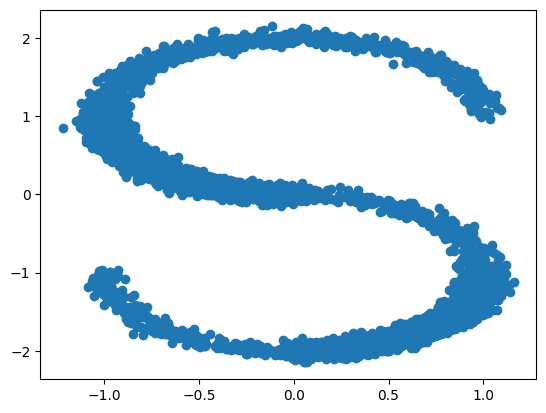

In [16]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, ax = plt.subplots()
ax.scatter(samples[:,0], samples[:, 1])
plt.show()

### Visualize the df_train_donor

In [11]:
adata.obs['donor'] = 0
adata.obs['technology'] = 'citeseq'
adata.obs['day'] = adata.obs['timepoint']
adata.obs['day_class'] = adata.obs['timepoint']

In [12]:
# save adata
# adata.write("adata_cite_all_donor-13176.h5ad")

In [23]:
from scipy.spatial.distance import pdist, squareform
from scipy import sparse as sp

def convert_data(X, colors, seed=42, test_size=0.1, knn=5, t='auto', n_components=3):
    # if X is sparse, convert to dense
    if sp.issparse(X):
        X = X.toarray()
        
    phate_op = PHATE(random_state=seed, t=t, n_components=n_components, knn=knn, verbose=True)
    _ = phate_op.fit(X)
    phate_data = np.zeros(1)

    dists = squareform(pdist(phate_op.diff_potential))

    return dict(
        data=X,
        colors=colors,
        dist=dists,
        phate=phate_data
    )

# data = convert_data(adata.obsm['X_pca'][:,:100], np.array(adata.obs['day_class'].tolist()))
data = convert_data(adata.X, np.array(adata.obs['day_class'].tolist()))

Running PHATE on 11250 observations and 2 variables.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 0.12 seconds.
  Calculating affinities...
  Calculated affinities in 0.02 seconds.
Calculated graph and diffusion operator in 0.14 seconds.
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 0.32 seconds.
  Calculating KMeans...
  Calculated KMeans in 1.10 seconds.
Calculated landmark operator in 1.68 seconds.
Calculating optimal t...
  Automatically selected t = 66
Calculated optimal t in 0.57 seconds.
Calculating diffusion potential...
Calculated diffusion potential in 0.25 seconds.


In [29]:
os.path.exists("data") 

True

In [30]:
print(data['data'].shape)
print(data['colors'].shape)
print(data['dist'].shape)
print(data['phate'].shape)

np.savez("data/gaga_s_imbalanced_adata.npz", data=data['data'], colors=data['colors'], dist=data['dist'], phate=data['phate'])

(11250, 2)
(11250,)
(11250, 11250)
(1,)


In [ ]:
###################

In [26]:
alpha=3.0
filename = f"gb_trajs_alpha{alpha}.t"

In [27]:
paths = torch.load(filename).cpu().detach()

In [28]:
paths.shape

torch.Size([100, 508, 3])

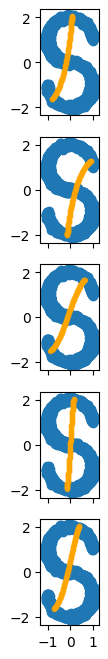

In [29]:
fig, ax = plt.subplots(5, figsize=(8,8), sharex=True, sharey=True)
for i in range(5):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')
plt.show()